In [2]:
!pip install statsmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 65.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 72.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

distances = pd.read_csv('../data/raw/distance_matrix.csv')
demand = pd.read_csv('../data/raw/historical_demand.csv')
stores = pd.read_csv('../data/raw/stores.csv')

treatment_cities = ['Agadir', 'Marrakech', 'Ouarzazate', 'Essaouira']
control_cities = ['Fès', 'Meknès', 'Béni Mellal']

did_data = demand[demand['city'].isin(treatment_cities + control_cities)].copy()

did_data['treated'] = did_data['city'].isin(treatment_cities).astype(int)

did_data['date'] = pd.to_datetime(did_data['date'])
did_data['after'] = (did_data['date'] >= '2023-07-01').astype(int)

did_data['treated_after'] = did_data['treated'] * did_data['after']

did_data['cost_per_tonne'] = did_data['demand_tonnes'] * 0.35

print(did_data[['city', 'date', 'treated', 'after', 'treated_after', 'cost_per_tonne']].head(20))
print(f"\nShape: {did_data.shape}")

   city       date  treated  after  treated_after  cost_per_tonne
48  Fès 2023-01-01        0      0              0          996.80
49  Fès 2023-02-01        0      0              0          893.55
50  Fès 2023-03-01        0      0              0         1294.65
51  Fès 2023-04-01        0      0              0          961.10
52  Fès 2023-05-01        0      0              0          946.75
53  Fès 2023-06-01        0      0              0         1212.05
54  Fès 2023-07-01        0      1              0         1030.40
55  Fès 2023-08-01        0      1              0         1025.50
56  Fès 2023-09-01        0      1              0          939.05
57  Fès 2023-10-01        0      1              0          964.95
58  Fès 2023-11-01        0      1              0          996.10
59  Fès 2023-12-01        0      1              0         1027.95
60  Fès 2024-01-01        0      1              0          956.55
61  Fès 2024-02-01        0      1              0          970.90
62  Fès 20

In [8]:
model = smf.ols('cost_per_tonne ~ treated + after + treated_after', data=did_data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         cost_per_tonne   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     3.886
Date:                Fri, 08 May 2026   Prob (F-statistic):             0.0102
Time:                        19:23:12   Log-Likelihood:                -1195.1
No. Observations:                 168   AIC:                             2398.
Df Residuals:                     164   BIC:                             2411.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       813.2833     70.936     11.465

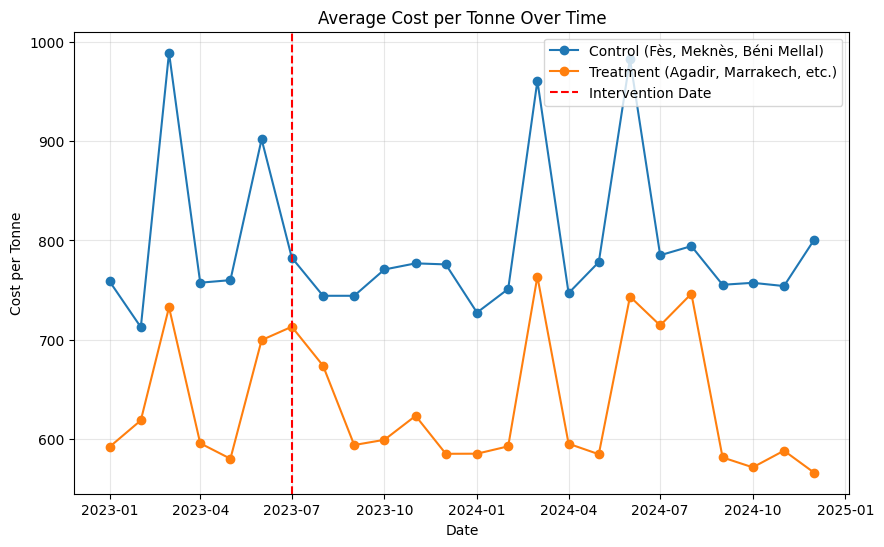

In [ ]:
monthly_data = did_data.groupby([did_data['date'].dt.to_period('M'), 'treated'])['cost_per_tonne'].mean().reset_index()
monthly_data['date'] = monthly_data['date'].dt.to_timestamp()

plt.figure(figsize=(10, 6))
plt.plot(monthly_data[monthly_data['treated'] == 0]['date'], 
         monthly_data[monthly_data['treated'] == 0]['cost_per_tonne'], 
         label='Control (Fès, Meknès, Béni Mellal)', marker='o')

plt.plot(monthly_data[monthly_data['treated'] == 1]['date'], 
         monthly_data[monthly_data['treated'] == 1]['cost_per_tonne'], 
         label='Treatment (Agadir, Marrakech, etc.)', marker='o')

plt.axvline(pd.to_datetime('2023-07-01'), color='red', linestyle='--', label='Intervention Date')
plt.title('Average Cost per Tonne Over Time')
plt.xlabel('Date')
plt.ylabel('Cost per Tonne')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Causal Inference Analysis Summary

#### 1. Setup & Methodology
* **Method used:** Difference-in-Differences (DiD) via OLS regression.
* **Treatment Group:** Agadir, Marrakech, Ouarzazate, Essaouira.
* **Control Group:** Fès, Meknès, Béni Mellal.
* **Intervention Date:** July 1, 2023.
* **Target Variable:** Average `cost_per_tonne`.

#### 2. Visual Inspection (Parallel Trends)
Prior to the intervention date, the average cost per tonne for both the treatment and control groups followed similar patterns, suggesting the parallel trends assumption holds reasonably well.

#### 3. Regression Results
* **DiD Estimator (`treated_after` coefficient):** 23.0741
* **P-value:** 0.832 (Not statistically significant)

#### Conclusion
There is **no statistically significant causal effect** resulting from the intervention on the target variable (`cost_per_tonne`). Because the p-value (0.832) is firmly above the standard 0.05 threshold, we fail to reject the null hypothesis. Any observed changes in the difference between the treatment and control groups after July 1, 2023, are indistinguishable from random variance.